In [2]:
import sys
import os
NOCOSDIR='/home/ubuntu/NOCOS'
# Define the absolute or relative path to the ridging directory
scrpath =f"{NOCOSDIR}/applications/NOCOS_DMI_ridfork/landfast/"

# Add the path to sys.path
sys.path.append(os.path.abspath(scrpath))

# Now you can import the modules
from read_config import read_configfile
#import read_ice_data
#import ridg_engine_NOCOS
cdir='/home/ubuntu/NOCOS/notebooks/rid/'
configs=read_configfile(f"{cdir}/config_lfast_calc_climdt.yml")

import xarray as xr
url = "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-o2d-v0.zarr"
ds = xr.open_dataset(
    url, 
    chunks={}, 
    engine="zarr", 
    storage_options={"client_kwargs": {"trust_env": True}}
)[["avg_siconc", "avg_sithick"]]
ds

#icedata=ds2;
icedata=ds.sel(latitude=slice(58, 66), longitude=slice(15, 25))

#from calculate_RID import calc_RID_intcat
#ridg_data=calc_RID_intcat(icedata,configs)
#ridg_data
# Example usage
#config = read_config.load_config("config_ridg_calc_REF.yml")  # Assuming a function like this exists
#data = read_ice_data.load_ice_data("some_data_file.nc")  # Example function





These are the configurations you have chosen:
{'ice_filename': 'iceh_inst.', 'path': '/data/users/imksie/NOCOS/landfast/datadir/', 'coordinates': {'time_name': 'time', 'lat_name': 'longitude', 'lon_name': 'latitude'}, 'variables': {'siu_name': 'avg_siue', 'siv_name': 'avg_sivn', 'siconc_name': 'avg_siconc'}, 'selectdata': {'Dformat': '%Y-%m-%d', 'end_year': 2022, 'end_month': 1, 'end_day': 2, 'start_year': 2022, 'start_month': 1, 'start_day': 1, 'freuqancy': 1}, 'output': {'filename_automatic': True, 'filename': 'LFoutupt.nc', 'output_folder': './outputLF/', 'title': 'land fast ice calculated from .... data'}}



In [12]:
#from LFengine_NOCOS import daterange
from read_config import read_configfile
from datetime import date, timedelta
import psutil
import numpy as np
import os
import xarray as xr
import pandas as pd
from subprocess import DEVNULL, STDOUT, check_call,call
import gc
import time # for sleep and cputime measurement
# Read config file
#cdir='/home/ubuntu/NOCOS/notebooks/rid/'
#print(f"{cdir}/config_lfast_calc_climdt.yml")
#configs=read_configfile(f"{cdir}/config_lfast_calc_climdt.yml") # Reads config_LFcalc_default.yml


In [13]:
print('current date =',current)
print('end date =',end_date)

icedataraw=xr.open_dataset(
    url, 
    chunks={}, 
    engine="zarr", 
    storage_options={"client_kwargs": {"trust_env": True}}
)[["avg_siconc", "avg_sithick","avg_siue","avg_sivn"]]
icedataraw=icedataraw.sel(latitude=slice(58, 66), longitude=slice(12, 25)).sel(time=slice(current,end_date))
print(icedataraw)

current date = 2022-01-01
end date = 2022-01-02
<xarray.Dataset> Size: 2MB
Dimensions:       (time: 2, latitude: 183, longitude: 295)
Coordinates:
  * latitude      (latitude) float64 1kB 58.0 58.04 58.09 ... 65.91 65.96 66.0
  * longitude     (longitude) float64 2kB 12.04 12.08 12.13 ... 24.92 24.96
    oceanSurface  float64 8B ...
    step          timedelta64[ns] 8B ...
  * time          (time) datetime64[ns] 16B 2022-01-01 2022-01-02
Data variables:
    avg_siconc    (time, latitude, longitude) float32 432kB dask.array<chunksize=(2, 183, 238), meta=np.ndarray>
    avg_sithick   (time, latitude, longitude) float32 432kB dask.array<chunksize=(2, 183, 238), meta=np.ndarray>
    avg_siue      (time, latitude, longitude) float32 432kB dask.array<chunksize=(2, 183, 238), meta=np.ndarray>
    avg_sivn      (time, latitude, longitude) float32 432kB dask.array<chunksize=(2, 183, 238), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB

In [14]:

outfile='aa.nc'
current=date(configs['selectdata']['start_year'],configs['selectdata']['start_month'],configs['selectdata']['start_day'])
end_date=date(configs['selectdata']['end_year'],configs['selectdata']['end_month'],configs['selectdata']['end_day'])


def daterange(start_date, end_date):
        for n in range(int((end_date - start_date).days)):
            yield start_date + timedelta(n)

while current<end_date:
    # Read ice data
#
#    if check_call(["ls", "runNOCOS_LF"], stdout=DEVNULL, stderr=STDOUT)!=0:
#        check_call(["mkdir" ,"runNOCOS_LF"])
#        print('made new run dir')

#    if call("test -e".format("runNOCOS_LF/*.nc"),shell=True, stdout=DEVNULL, stderr=STDOUT)==0:
#        call("rm runNOCOS_LF/*.nc",shell=True)


 #   for single_date in daterange(current, current+timedelta(7)):
 #       datenow=single_date.strftime(configs['selectdata']['Dformat'])
 #       if check_call(["ls " + configs['path']+configs['ice_filename']+datenow+"*.nc"],shell=True, stdout=DEVNULL, stderr=STDOUT)==0:
 #           check_call(["ln -s "+configs['path']+configs['ice_filename']+datenow+"*.nc runNOCOS_LF/."],shell=True, stdout=DEVNULL, stderr=STDOUT)
 #       else:
 #           print('the files you are trying to proccess are not existing, please check you *.yml file ')

#    if check_call(["ls /home/imksie/runNOCOS/runNOCOS_LF/*.nc"],shell=True, stdout=DEVNULL, stderr=STDOUT)==0:
#        print('open files')
#        icedataraw = xr.open_mfdataset("runNOCOS_LF/*.nc")
    relevantvars_list=[configs['variables']['siconc_name'], configs['variables']['siu_name'], configs['variables']['siv_name']]
    rename_vardict={configs['variables']['siconc_name']:'siconc', configs['variables']['siu_name']:'siu', configs['variables']['siv_name']:'siv'}
    icedataraw.close()
    icedata = icedataraw[relevantvars_list].rename(rename_vardict)

    print('RAM memory % used:', psutil.virtual_memory()[2])
    # Create the output filename
#    if configs['output']['filename_automatic']==True:
#        outfile=configs['output']['output_folder']+'/LF-_'+os.path.basename(configs['ice_filename']).replace('*','XXX').replace('?','X')+current.strftime(configs['selectdata']['Dformat'])+'.nc'
#    else:
#        outfile=configs['output']['output_folder']+'/'+current.strftime(configs['selectdata']['Dformat'])+configs['output']['filename']+'.nc'

    # Make an empty dataset with basic coordinates for the netcdf file, copied from the icedata-file
    lfdata=icedata.siconc.isel(time=1)
    #print('RAM memory % used before calcLF:', psutil.virtual_memory()[2])
    ############################calculatet LF area##################################################
    ny = icedata.siu.shape[1] # Number of grid points in y-direction
    nx = icedata.siu.shape[2] # Number of grid points in x-direction
    # Set up an empty output array
    lffinal=np.array(np.nan*np.zeros([ny,nx]))
    cputime=time.time()
    # 7 days are needed to eusre that no data point in the central arctic are included
    d1=current+timedelta(7)
    #calculating velociety
    speed=np.sqrt((icedata.siv.sel(time=slice(str(current), str(d1))).where(icedata.siconc.sel(time=slice(str(current), str(d1)))>0.15)**2 +icedata.siu.sel(time=slice(str(current), str(d1))).where(icedata.siconc.sel(time=slice(str(current), str(d1)))>0.15)**2)/2)
    #mask spans all time steps within the one week fom which the landfast ice is calculated
    mask=np.zeros(speed.shape)+1
    #speed < 5.e-04 is the first condition for landfast ice
    mask[speed.values>=5.e-04]=np.nan
    #sic > 15% is the condition condition for landfast ice
    mask[np.isnan(icedata.siconc.values)]=np.nan
    mask[icedata.siconc.sel(time=slice(str(current), str(d1))).values<0.15]=np.nan
    Mmask=np.nansum(mask[:,:,:],0)
    #timsepts within 7 days
    ll=speed.shape[0]
    #the first and second conditions need to be fullfild over 7 days
    Mmask[Mmask<ll]=np.nan
    Mmask[~np.isnan(Mmask)]=1
    lffinal[:,:]=Mmask
    print("Calculation time: "+str(int(time.time()-cputime))+' s')
    del d1
    del cputime
    del ny
    del nx
    del(ll)
    del(mask)
    del(speed)
    del Mmask

    lfdata.values=lffinal #calcLF(icedata,configs,current)
    #print('RAM memory % used after calcLF:', psutil.virtual_memory()[2])
    lfdata=lfdata.rename('LFmask')
    lfdata.attrs['long_name']='landfast ice mask'
    #print('RAM memory % before make ds:', psutil.virtual_memory()[2])
    ds = xr.Dataset({'LFmask':lfdata})   # enter data here
    #print('RAM memory % used after make ds:', psutil.virtual_memory()[2])
    # Write netcdf file
    ds=ds.drop('longitude')
    ds=ds.drop('latitude')
    #print(ds)
    lfdata.close()
    #print('RAM memory % before save ds:', psutil.virtual_memory()[2])
    ds.to_netcdf(outfile, unlimited_dims=configs["coordinates"]["time_name"],encoding={'time':{"dtype": "double", 'units': "days since 1900-01-01 00:00:00"}})
    #print('RAM memory % after save ds:', psutil.virtual_memory()[2])
    ds.close()
    #print('RAM memory % after close ds:', psutil.virtual_memory()[2])
    del lffinal
    del lfdata
#    del ds
#    del icedata
#    del datenow
#    del relevantvars_list
#    del rename_vardict
#    del icedataraw 
    gc.collect()
    print('RAM memory % used after del:', psutil.virtual_memory()[2])
    current=current+timedelta(configs['selectdata']['freuqancy'])


RAM memory % used: 51.0
Calculation time: 1 s


/tmp/ipykernel_1263521/3551654816.py:88: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds=ds.drop('longitude')
/tmp/ipykernel_1263521/3551654816.py:89: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds=ds.drop('latitude')


RAM memory % used after del: 50.9


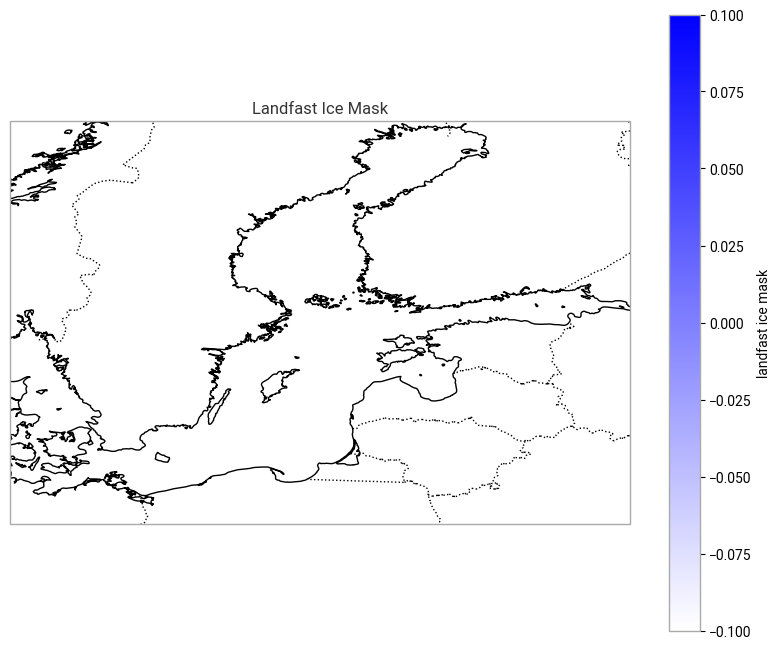

In [17]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap

# Open the dataset
ds = xr.open_dataset("aa.nc")
lfmask = ds["LFmask"]

# If the LFmask variable does not have proper latitude/longitude coordinates,
# assign them manually. (Adjust the bounds to match your dataset's actual extents.)
lat_vals = np.linspace(-90, 90, lfmask.sizes['latitude'])
lon_vals = np.linspace(-180, 180, lfmask.sizes['longitude'])
lfmask = lfmask.assign_coords(latitude=lat_vals, longitude=lon_vals)

# Create a custom colormap from white to blue
custom_cmap = LinearSegmentedColormap.from_list('white_blue', ['white', 'blue'])

# Create a figure with a PlateCarree projection
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set the map extent based on the assigned coordinates
ax.set_extent([lon_vals.min(), lon_vals.max(), lat_vals.min(), lat_vals.max()], crs=ccrs.PlateCarree())

# Add coastlines and borders for context
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
# Set the extent to the Baltic Sea region
ax.set_extent([10, 30, 53, 66], crs=ccrs.PlateCarree())

# Plot the data using pcolormesh; ensure the transform is set correctly
mesh = ax.pcolormesh(lfmask.longitude, lfmask.latitude, lfmask.values,
                     transform=ccrs.PlateCarree(), cmap=custom_cmap)

# Add a colorbar with the variable's long name (or a default label)
plt.colorbar(mesh, ax=ax, orientation='vertical', label=lfmask.attrs.get('long_name', 'LFmask'))
plt.title("Landfast Ice Mask")
plt.show()
